# Exploración del dataset Diabetes Readmission

Notebook propio de exploración (EDA) del dataset `diabetes_readmission` (vía TableShift), para entender
su estructura antes de seguir trabajando con el inyector de concept drift. Complementa —no reemplaza—
los notebooks de perfilado de datos ya existentes en el repo
(`diabetes_readmission_data_profiling.ipynb`, `diabetes_readmission_distributions.ipynb`).

**Origen:** UCI "Diabetes 130-US hospitals for years 1999-2008". Variable objetivo: `readmitted`
(binaria: reingreso a cualquier plazo vs. sin reingreso registrado). El split train/id_test de
TableShift separa por `admission_source_id` (dominio objetivo: Emergency Room).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darl.data.get_dataset import load_dataset

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

LABEL_COL = "readmitted"

dset = load_dataset("diabetes_readmission")
X_train, y_train, _, _ = dset.get_pandas(split="train")
X_target, y_target, _, _ = dset.get_pandas(split="id_test")

df_train = X_train.copy()
df_train[LABEL_COL] = y_train.values
df_target = X_target.copy()
df_target[LABEL_COL] = y_target.values

print(f"Train : {df_train.shape}")
print(f"Target: {df_target.shape}")

C:\Users\dayan\OneDrive\Documentos\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Train : (34288, 47)
Target: (4287, 47)


## 1. Variable objetivo (`readmitted`)

Prevalencia train : 0.4242300513299113
Prevalencia target: 0.41614182411943085


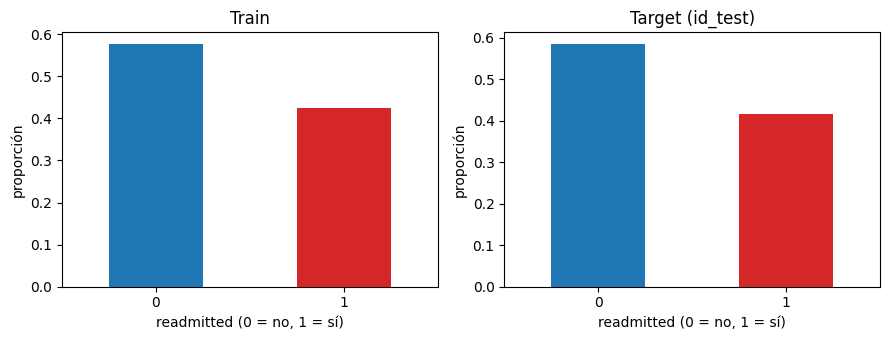

In [2]:
print("Prevalencia train :", df_train[LABEL_COL].mean())
print("Prevalencia target:", df_target[LABEL_COL].mean())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, df, title in zip(axes, [df_train, df_target], ["Train", "Target (id_test)"]):
    df[LABEL_COL].value_counts(normalize=True).sort_index().plot.bar(ax=ax, color=["#1f77b4", "#d62728"])
    ax.set_title(title)
    ax.set_xlabel("readmitted (0 = no, 1 = sí)")
    ax.set_ylabel("proporción")
    ax.set_xticklabels(["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

## 2. Panorama general de columnas

Cuántas columnas son numéricas vs. categóricas, y cuáles tienen valores faltantes.

In [3]:
dtypes_summary = df_train.dtypes.value_counts()
print(dtypes_summary)

missing = df_train.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print("\nColumnas con datos faltantes (train):")
print(missing if len(missing) else "Ninguna")

object     34
float64     9
int64       4
Name: count, dtype: int64

Columnas con datos faltantes (train):
weight               0.958207
max_glu_serum        0.905419
A1Cresult            0.873629
payer_code           0.450945
medical_specialty    0.403523
diag_3               0.017295
diag_2               0.003966
diag_1               0.000321
dtype: float64


## 3. Variables numéricas de conteo (las que usa el inyector de concept drift)

Estas 8 variables representan historial de hospitalización y utilización de servicios — son las mismas
que ya usa `ConceptDriftInjector` en `diabetes_drift_injector.ipynb`, y coinciden con la selección
independiente hecha en `diabetes_readmission_distributions.ipynb`.

                      count       mean        std  min   25%   50%   75%    max
time_in_hospital    34288.0   4.416618   3.060285  1.0   2.0   4.0   6.0   14.0
num_lab_procedures  34288.0  37.478097  19.501685  1.0  24.0  38.0  51.0  118.0
num_procedures      34288.0   1.727835   1.820896  0.0   0.0   1.0   3.0    6.0
num_medications     34288.0  17.051009   8.838732  1.0  11.0  15.0  21.0   81.0
number_outpatient   34288.0   0.393024   1.251448  0.0   0.0   0.0   0.0   36.0
number_emergency    34288.0   0.138853   0.738705  0.0   0.0   0.0   0.0   76.0
number_inpatient    34288.0   0.535756   1.105909  0.0   0.0   0.0   1.0   17.0
number_diagnoses    34288.0   7.147836   1.994126  1.0   5.0   8.0   9.0   16.0


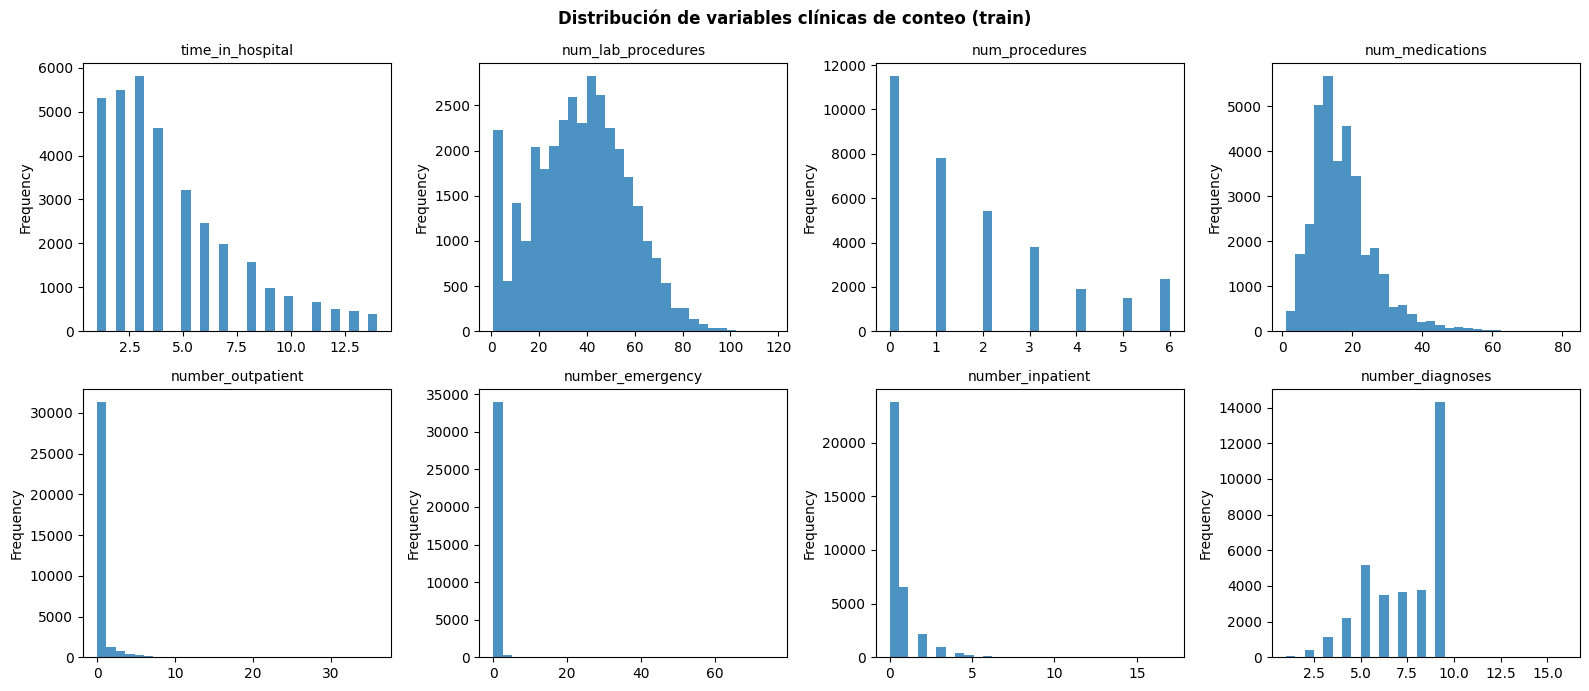

In [4]:
CLINICAL_VARS = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]

print(df_train[CLINICAL_VARS].describe().T)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), CLINICAL_VARS):
    df_train[col].plot.hist(ax=ax, bins=30, color="#1f77b4", alpha=0.8)
    ax.set_title(col, fontsize=10)
plt.suptitle("Distribución de variables clínicas de conteo (train)", fontweight="bold")
plt.tight_layout()
plt.show()

**Nota:** varias de estas variables están muy concentradas en 0 (p. ej. `number_emergency`,
`number_outpatient`, `number_inpatient`) — esto es justo lo que causó el bug de `DriftInjector` que
documentamos en `compatibility_combined_drift_diabetes.ipynb` (el `EPS` interno desplaza esa masa en 0
incluso a severidad 0).

In [5]:
zero_share = (df_train[CLINICAL_VARS] == 0).mean().sort_values(ascending=False)
print("Proporción de filas exactamente en 0, por variable:")
print(zero_share)

Proporción de filas exactamente en 0, por variable:
number_emergency      0.912010
number_outpatient     0.820404
number_inpatient      0.693508
num_procedures        0.335482
num_medications       0.000000
num_lab_procedures    0.000000
time_in_hospital      0.000000
number_diagnoses      0.000000
dtype: float64


## 4. Variables categóricas clave

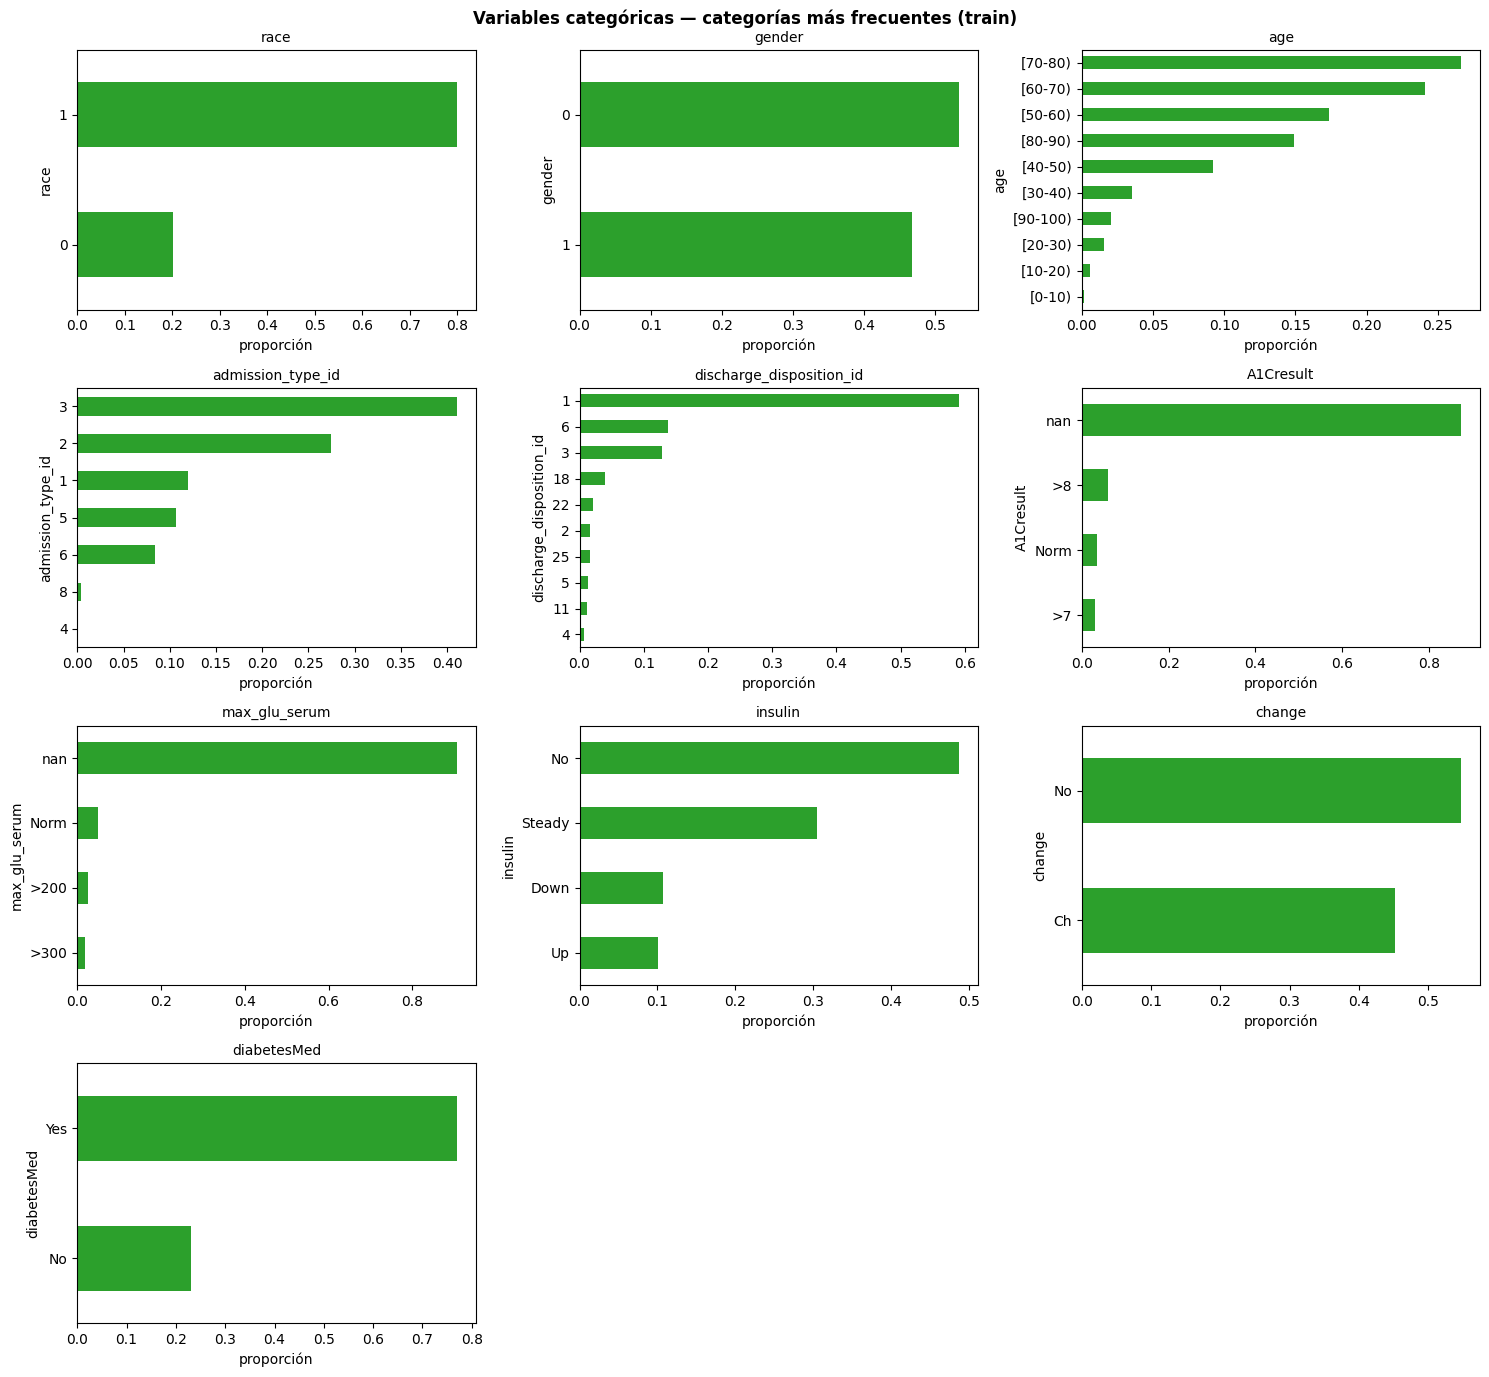

In [6]:
CATEGORICAL_VARS = [
    "race", "gender", "age", "admission_type_id", "discharge_disposition_id",
    "admission_source_id", "A1Cresult", "max_glu_serum", "insulin", "change", "diabetesMed",
]
CATEGORICAL_VARS = [c for c in CATEGORICAL_VARS if c in df_train.columns]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
for ax, col in zip(axes.flatten(), CATEGORICAL_VARS):
    counts = df_train[col].astype(str).value_counts(normalize=True).head(10)
    counts.sort_values().plot.barh(ax=ax, color="#2ca02c")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("proporción")
for ax in axes.flatten()[len(CATEGORICAL_VARS):]:
    ax.axis("off")
plt.suptitle("Variables categóricas — categorías más frecuentes (train)", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Reingreso por grupo — algunas relaciones simples

Para dar contexto clínico: ¿el riesgo de reingreso varía mucho según edad o fuente de admisión?

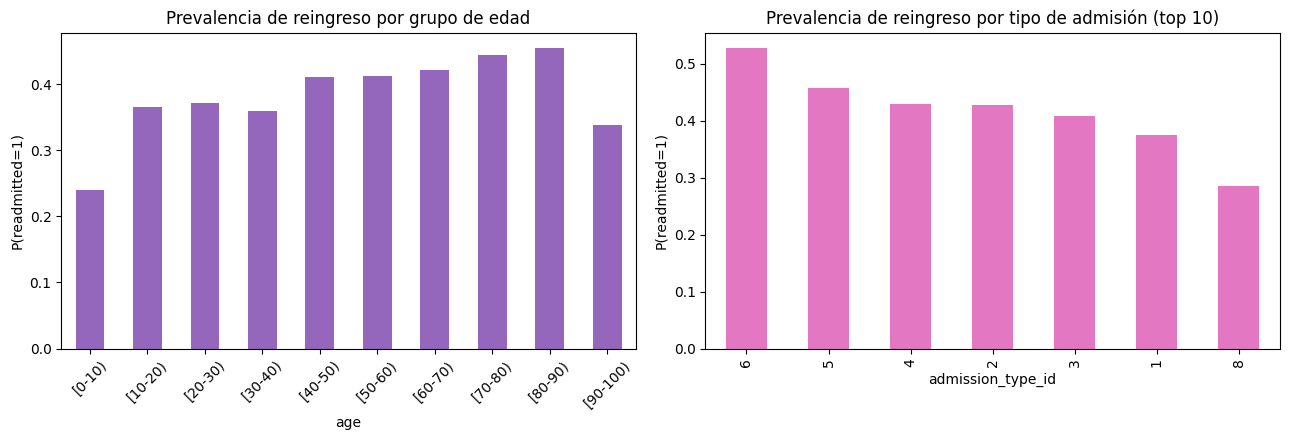

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

age_risk = df_train.groupby("age")[LABEL_COL].mean().sort_index()
age_risk.plot.bar(ax=axes[0], color="#9467bd")
axes[0].set_title("Prevalencia de reingreso por grupo de edad")
axes[0].set_ylabel("P(readmitted=1)")
axes[0].tick_params(axis="x", rotation=45)

admtype_risk = df_train.groupby("admission_type_id")[LABEL_COL].mean().sort_values(ascending=False).head(10)
admtype_risk.plot.bar(ax=axes[1], color="#e377c2")
axes[1].set_title("Prevalencia de reingreso por tipo de admisión (top 10)")
axes[1].set_ylabel("P(readmitted=1)")

plt.tight_layout()
plt.show()

## 6. Correlación entre las variables numéricas de conteo

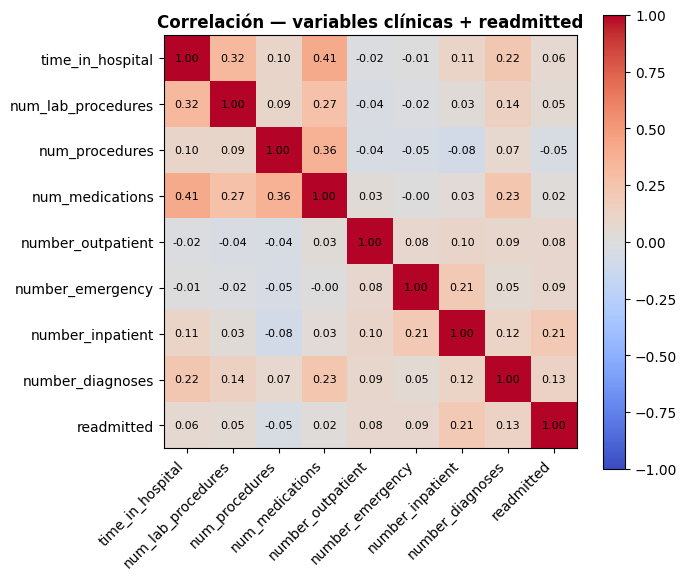

In [8]:
corr = df_train[CLINICAL_VARS + [LABEL_COL]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlación — variables clínicas + readmitted", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Conclusiones

- El dataset no tiene ninguna columna de fecha ni ID de encuentro — no es posible construir un eje de
  tiempo real para esta base (a diferencia de Physionet).
- `time_in_hospital` está en días (1 a 14), sin mayor granularidad disponible en la fuente original.
- Las 8 variables de conteo clínico están fuertemente concentradas en 0 para varias de ellas —
  relevante para entender por qué el covariate shift se comporta distinto aquí que en Physionet.
- `readmitted` tiene una prevalencia balanceada (~42%), muy distinta a la de sepsis en Physionet
  (~1.2%) — esto es lo que explica por qué el concept drift funciona diferente en cada dataset.